In [1]:
import sys
from torch.profiler import profile, ProfilerActivity, record_function
import tensorly as tl
import itertools
from torch.utils.data import DataLoader
import torchinfo
from functools import partial
from typing import Literal
from tdecomp.grad_proj.tensorgrad.prepared_tg import ParallelTG

TDECOMP_PATH = '..'
if not TDECOMP_PATH in sys.path:
    sys.path.append(TDECOMP_PATH)

import mlflow
import os

mlflow.set_tracking_uri("http://172.19.0.1:5000")
mlflow.set_experiment("qwen-exp-draft-glazkov")
mlFlowClient = mlflow.MlflowClient()
# client = mlflow.server.get_app_client("basic-auth", "http://172.19.0.1:5000")
# client.create_user(username="minio", password="minio123")
# # mlflow.export

os.environ["AWS_ACCESS_KEY_ID"] = "minio"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minio123"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = f"http://172.19.0.1:9000" #https://github.com/mlflow/mlflow/issues/2150


2026-03-04 14:48:59.592343: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 14:48:59.656322: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 14:49:01.137153: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/tdecomp/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgr

In [2]:
from mlflow_metrics_pandas_converter import MlflowMetricsPandasConverter
mlflowpandasconverter = MlflowMetricsPandasConverter(mlFlowClient)

In [3]:
mem_params = ['mem_weights_mb', 'mem_grads_mb', 'mem_opt_state_mb', 'mem_activations_estimate_mb', 'mem_activations_peak_during_one_step_est_mb']
optimizer_params = ['rank', 'sparse_ratio', 'lambda_sparse', 'update_gap', 'update_gap_mode', 'optimizer_type']
other_params = ['context_length']

all_params = mem_params + optimizer_params + other_params

In [4]:
df = mlflowpandasconverter.get_metrics_from_all_experiment_runs("63", include_parameters=all_params)

In [5]:
df['run_name']

0     perebor_{'rank': 896, 'sparse_ratio': 0.2, 'la...
1     perebor_{'rank': 896, 'sparse_ratio': 0.2, 'la...
2     perebor_{'rank': 896, 'sparse_ratio': 0.2, 'la...
3     perebor_{'rank': 896, 'sparse_ratio': 0.2, 'la...
4     perebor_{'rank': 896, 'sparse_ratio': 0.2, 'la...
                            ...                        
36    perebor_{'rank': 896, 'sparse_ratio': 0.05, 'l...
37    perebor_{'rank': 896, 'sparse_ratio': 0.05, 'l...
38    perebor_{'rank': 896, 'sparse_ratio': 0.05, 'l...
39    perebor_{'rank': 896, 'sparse_ratio': 0.05, 'l...
40    perebor_{'rank': 896, 'sparse_ratio': 0.05, 'l...
Name: run_name, Length: 1330, dtype: object

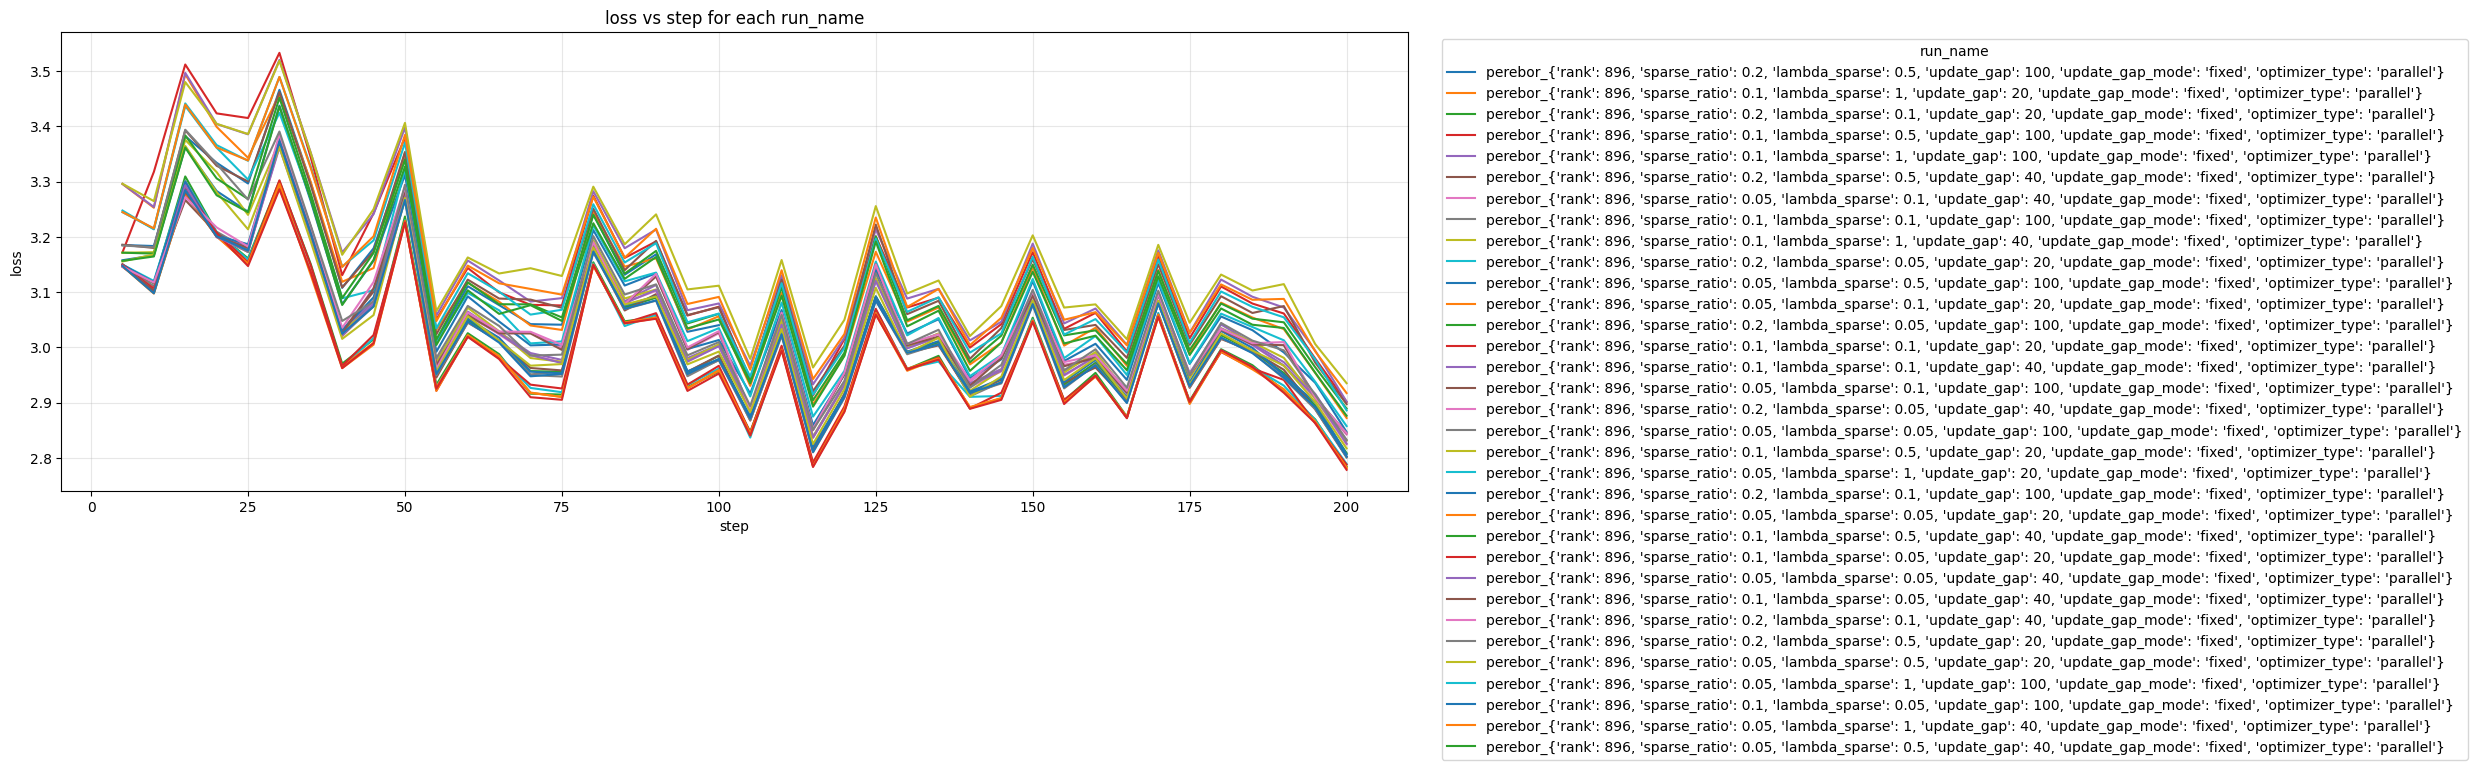

(<Figure size 2500x700 with 1 Axes>,
 <Axes: title={'center': 'loss vs step for each run_name'}, xlabel='step', ylabel='loss'>)

In [6]:
from examples.metric_visualizer import MetricVisualizer
import importlib
import examples.metric_visualizer
importlib.reload(examples.metric_visualizer)

MetricVisualizer().plot_metric_by_run(df, 'loss', figsize=(25, 7))

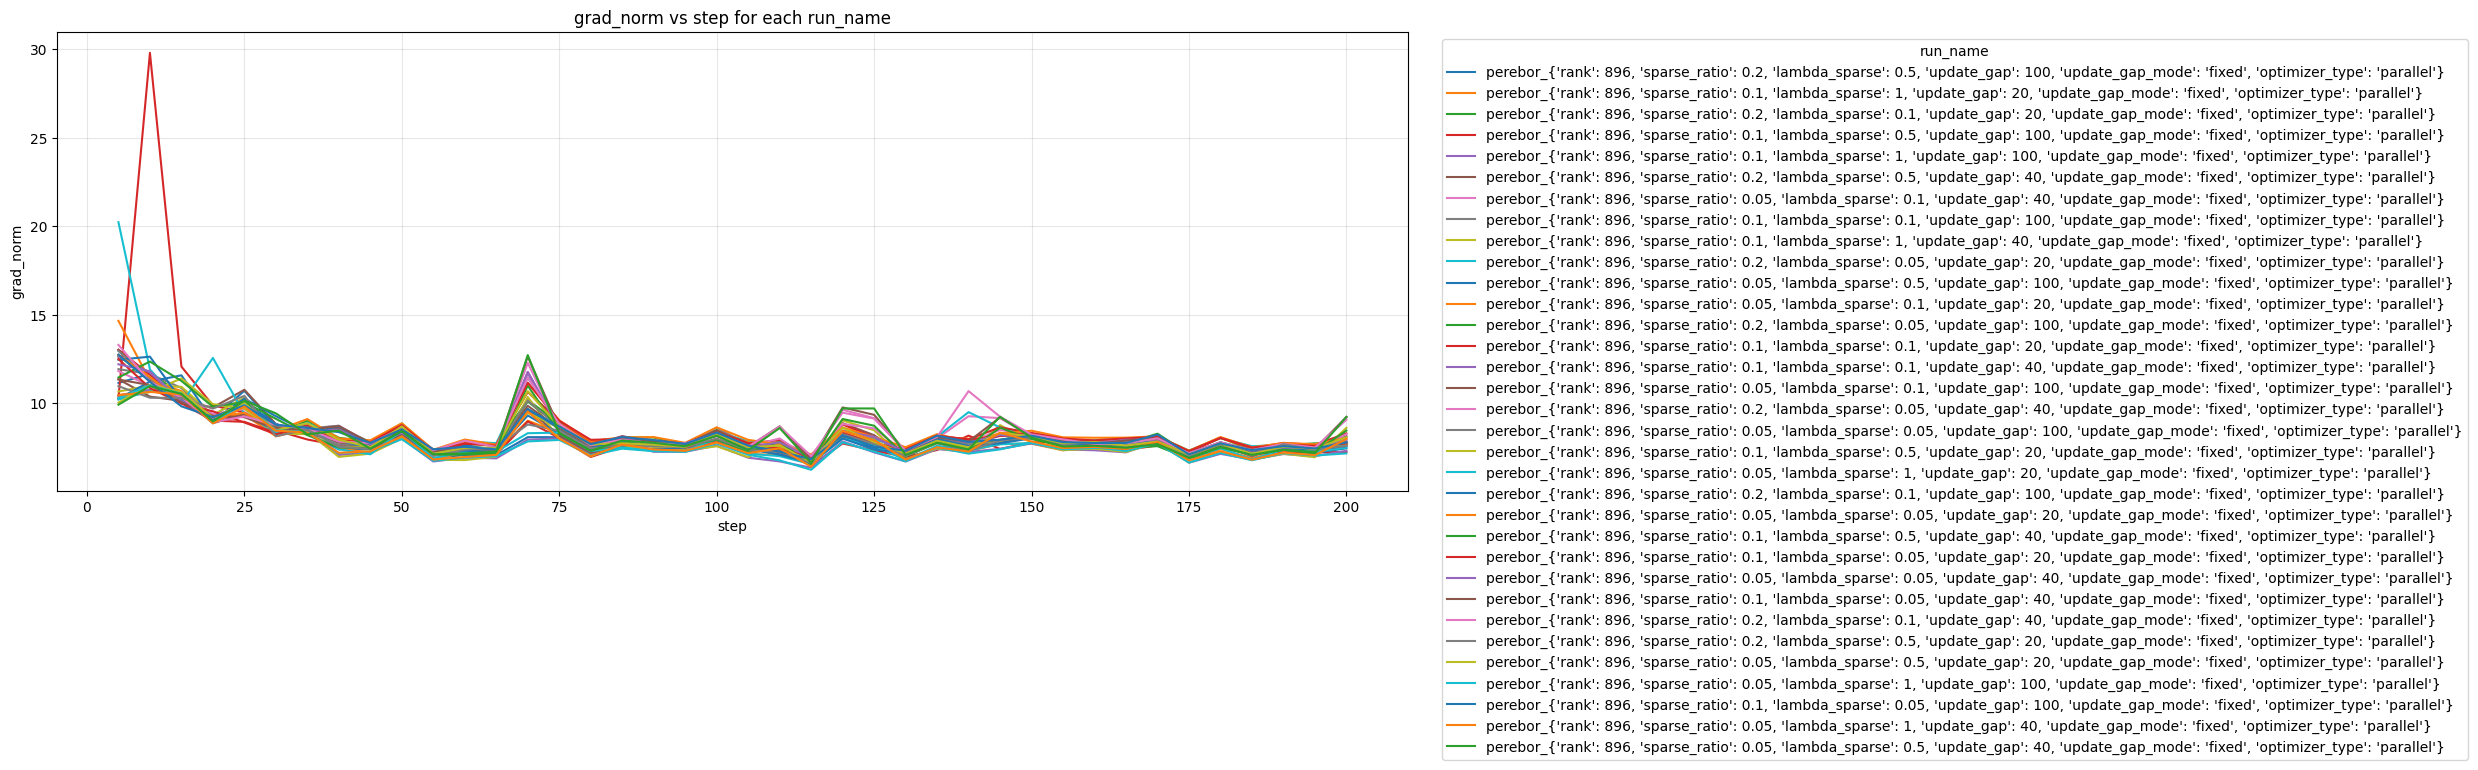

(<Figure size 2500x700 with 1 Axes>,
 <Axes: title={'center': 'grad_norm vs step for each run_name'}, xlabel='step', ylabel='grad_norm'>)

In [7]:
MetricVisualizer().plot_metric_by_run(df, 'grad_norm', figsize=(25, 7))

In [20]:
df.groupby("run_id").last().groupby('sparse_ratio')['loss'].mean()

sparse_ratio
0.05    2.836053
0.1     2.847840
0.2     2.847255
Name: loss, dtype: float64

In [21]:
df.groupby("run_id").last().groupby('lambda_sparse')['loss'].mean()

lambda_sparse
0.05    2.806056
0.1     2.808708
0.5     2.881178
1       2.894757
Name: loss, dtype: float64

In [22]:
df.groupby("run_id").last().groupby('update_gap')['loss'].mean()

update_gap
100    2.854088
20     2.810143
40     2.865952
Name: loss, dtype: float64

In [ ]:
df.groupby("run_id")[['grad_norm', 'sparse_ratio']].mean().groupby('sparse_ratio')

KeyError: 'sparse_ratio'

In [8]:
df['loss']

0     3.185082
1     3.183251
2     3.382105
3     3.333943
4     3.296405
        ...   
36    2.959996
37    2.924092
38    2.864590
39    2.782405
40    2.782405
Name: loss, Length: 1330, dtype: float64

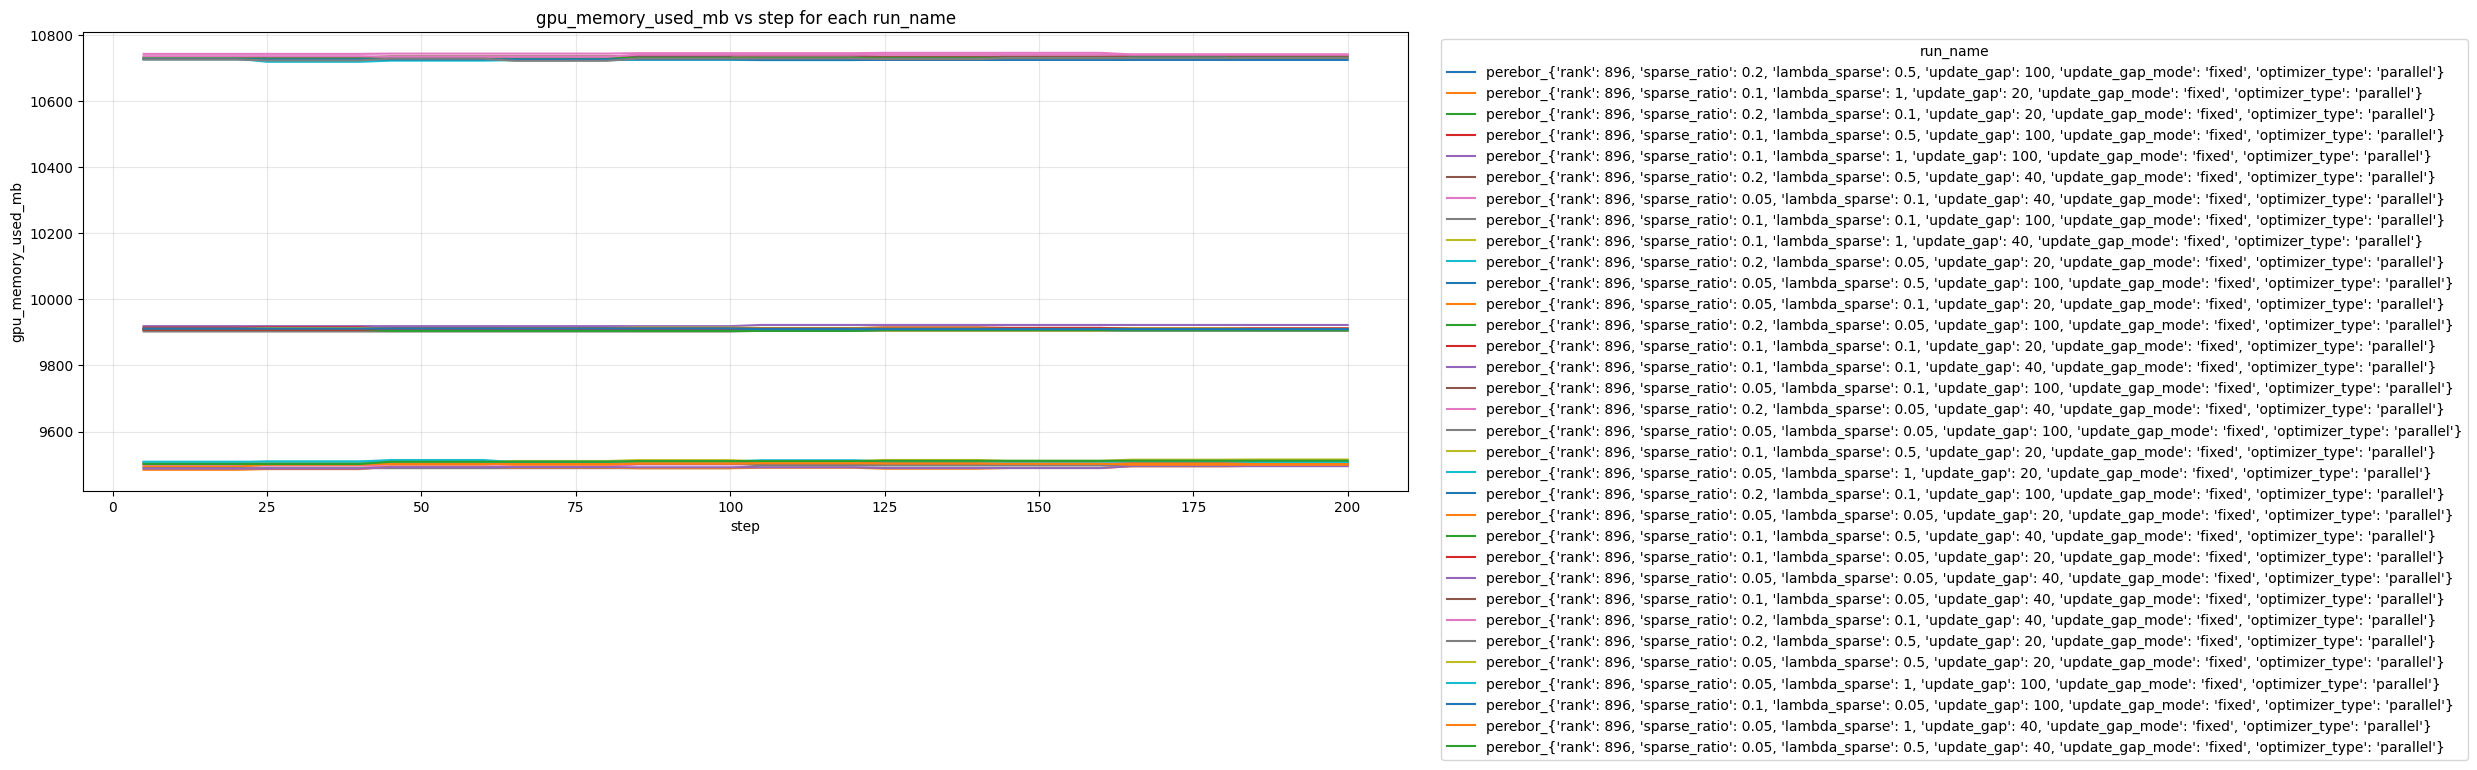

(<Figure size 2500x700 with 1 Axes>,
 <Axes: title={'center': 'gpu_memory_used_mb vs step for each run_name'}, xlabel='step', ylabel='gpu_memory_used_mb'>)

In [11]:
MetricVisualizer().plot_metric_by_run(df, 'gpu_memory_used_mb', figsize=(25, 7))

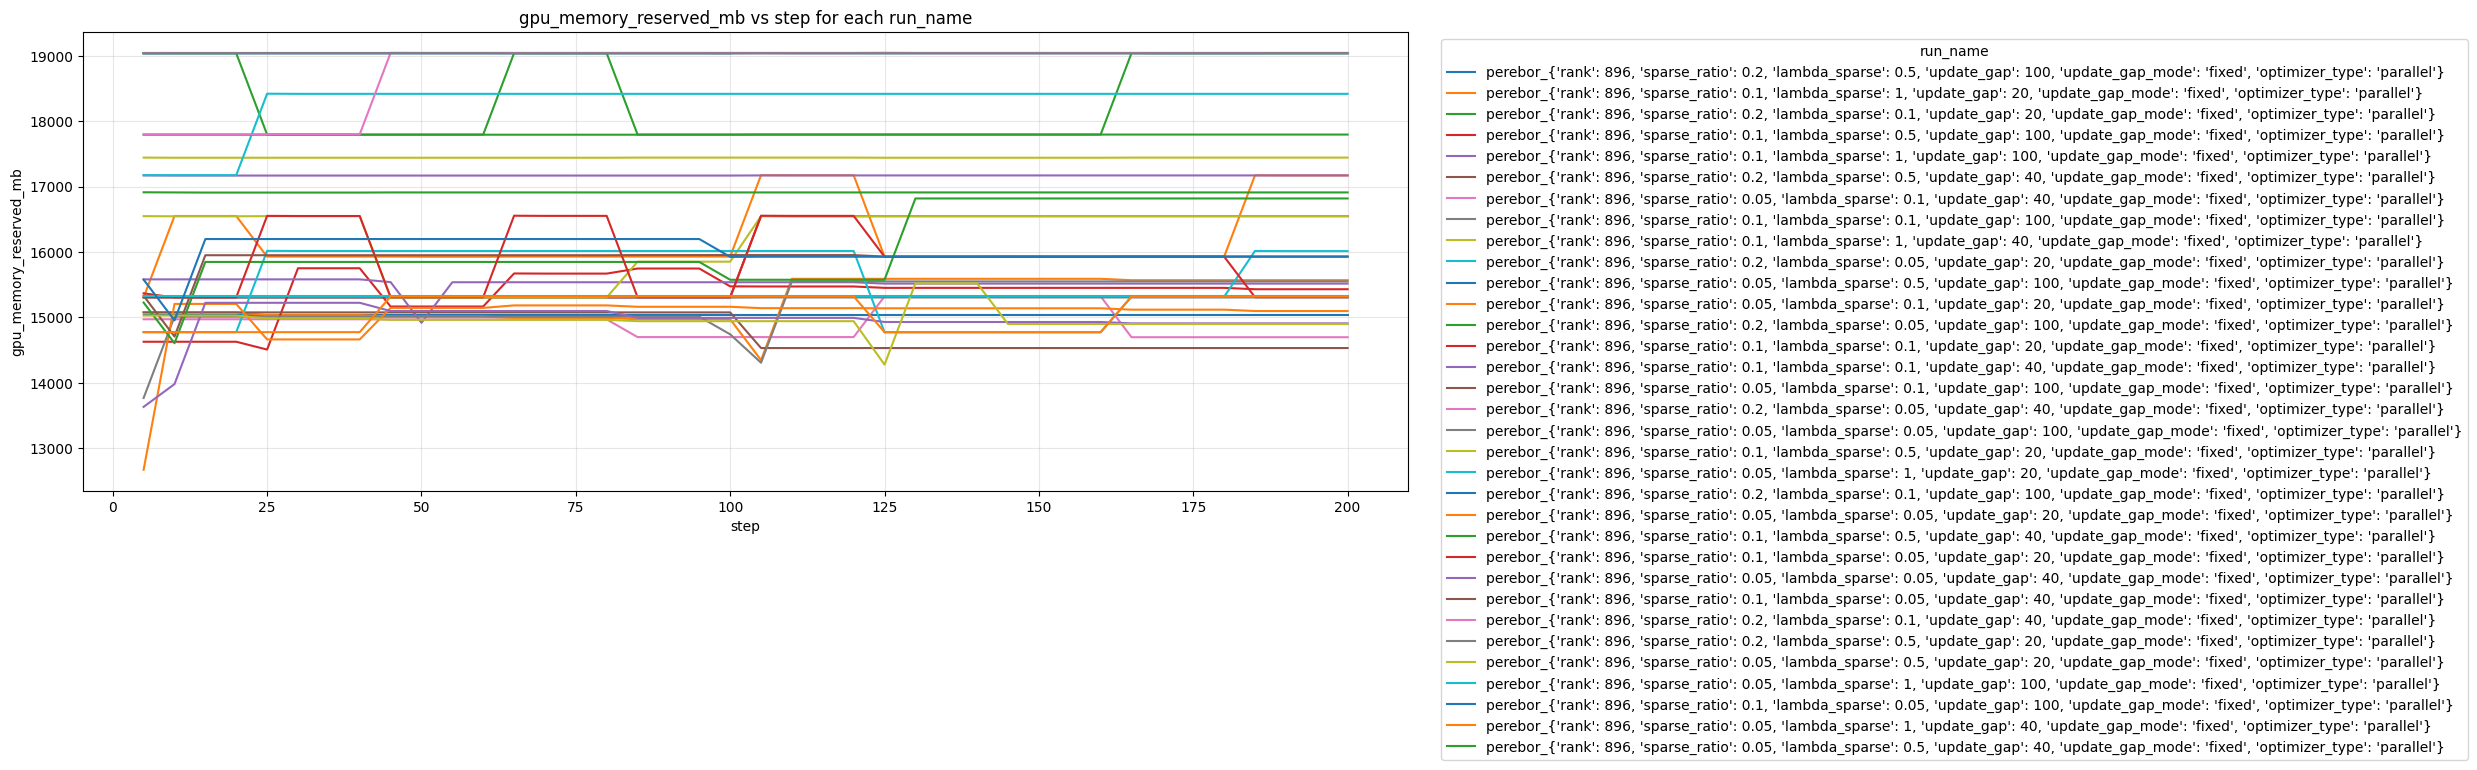

(<Figure size 2500x700 with 1 Axes>,
 <Axes: title={'center': 'gpu_memory_reserved_mb vs step for each run_name'}, xlabel='step', ylabel='gpu_memory_reserved_mb'>)

In [10]:
MetricVisualizer().plot_metric_by_run(df, 'gpu_memory_reserved_mb', figsize=(25, 7))